**This notebook is not properly formatted and is not written for beginners to understand in one go. kindly follow [these](https://youtube.com/playlist?list=PLeo1K3hjS3uvaRHZLl-jLovIjBP14QTXc&si=QvqFyZk640427pv0) tutorials if you need to understand it**

In [8]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
import os, shutil
import pywt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import pandas as pd

In [9]:
img = cv2.imread('.\\test_images\\kohli_1.jpg')
img.shape

(720, 1280, 3)

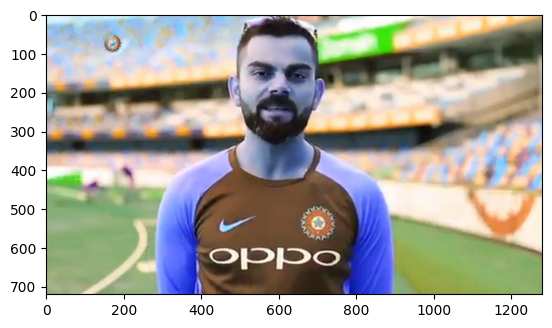

In [10]:
plt.imshow(img)

In [11]:
face_cascade = cv2.CascadeClassifier('.\\opencv\\haarcascades\\haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(img, 1.3, 5)
faces

array([[483,  64, 234, 234]], dtype=int32)

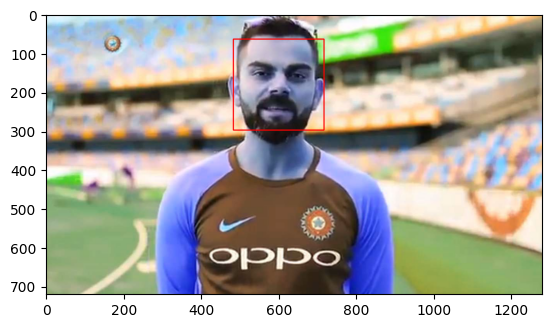

In [12]:
(x,y,w,h) = faces[0]
detected_face_img = cv2.rectangle(img, (x,y), (x+w,y+h), (255,0,0), 2)
plt.imshow(detected_face_img)

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

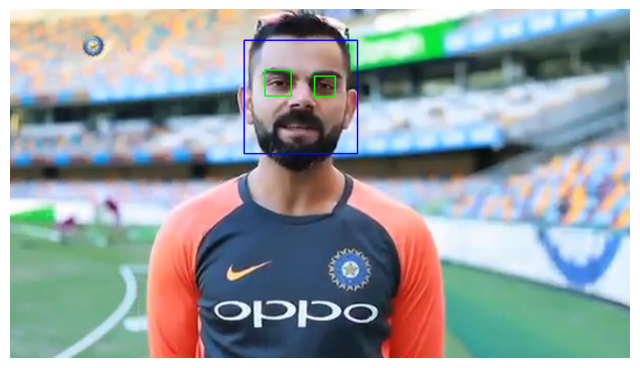

In [13]:
# Start from image that already has the face rectangle
img_clean = detected_face_img.copy()

gray = cv2.cvtColor(img_clean, cv2.COLOR_BGR2GRAY)

for (x, y, w, h) in faces:
    face_gray = gray[y:y+h, x:x+w]
    face_color = img_clean[y:y+h, x:x+w]

    # Detect eyes only inside the face ROI for cleaner results
    eye_cascade = cv2.CascadeClassifier('.\\opencv\\haarcascades\\haarcascade_eye.xml')
    eyes = eye_cascade.detectMultiScale(
        face_gray,
        scaleFactor=1.1,
        minNeighbors=8,
        minSize=(20, 20)
    )

    # Green rectangles for eyes
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(face_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [14]:
def croptofrontface(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_color = img[y:y+h, x:x+w]
        roi_gray = gray[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

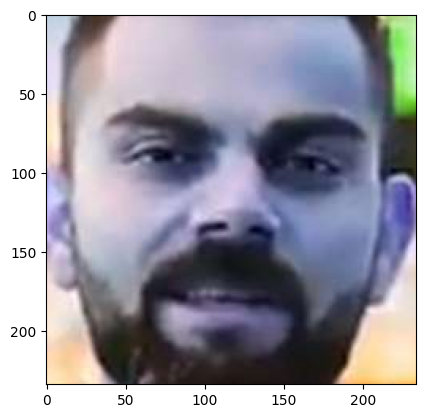

In [15]:
#checking the function
cropped_img = croptofrontface('.\\test_images\\kohli_1.jpg')
plt.imshow(cropped_img)

In [19]:
#testing the function with no front face
cropped_img = croptofrontface('.\\images_dataset\\serena_williams\\serena_williams_3.jpg')
cropped_img

array([[[237, 239, 233],
        [237, 238, 234],
        [237, 238, 234],
        ...,
        [ 17,  22,  31],
        [  9,  14,  23],
        [  6,  11,  20]],

       [[237, 240, 231],
        [237, 239, 233],
        [237, 238, 234],
        ...,
        [ 20,  26,  33],
        [ 13,  18,  27],
        [ 11,  16,  25]],

       [[237, 240, 231],
        [237, 239, 233],
        [237, 238, 234],
        ...,
        [ 13,  19,  26],
        [  9,  14,  23],
        [ 11,  16,  25]],

       ...,

       [[  7,   9,  19],
        [ 16,  17,  31],
        [ 17,  20,  35],
        ...,
        [ 31,  43,  85],
        [ 36,  49,  93],
        [ 44,  59, 105]],

       [[  9,  11,  21],
        [ 22,  23,  37],
        [ 22,  25,  39],
        ...,
        [ 33,  46,  90],
        [ 38,  53,  99],
        [ 48,  64, 111]],

       [[  9,  13,  24],
        [ 19,  21,  32],
        [ 20,  22,  33],
        ...,
        [ 30,  44,  92],
        [ 43,  58, 107],
        [ 53,  70, 121]]

In [ ]:
dataset_dir = '.\\images_dataset'
cropped_dir = '.\\cropped'

In [ ]:
img_dirs = []
for dir in os.scandir(dataset_dir):
    if dir.is_dir():
        img_dirs.append(dir.path)

In [ ]:
img_dirs

['.\\images_dataset\\lionel_messi',
 '.\\images_dataset\\maria_sharapova',
 '.\\images_dataset\\roger_federer',
 '.\\images_dataset\\serena_williams',
 '.\\images_dataset\\virat_kohli']

In [ ]:
if os.path.exists(cropped_dir):
    shutil.rmtree(cropped_dir)

os.mkdir(cropped_dir)

In [ ]:
celeb_names = [x.split('\\')[-1] for x in img_dirs]
celeb_names

['lionel_messi',
 'maria_sharapova',
 'roger_federer',
 'serena_williams',
 'virat_kohli']

In [17]:
for celeb_dir in img_dirs:
    celeb_name = os.path.basename(celeb_dir)
    celeb_target_dir = os.path.join(cropped_dir, celeb_name)

    if not os.path.exists(celeb_target_dir):
        print(f'creating dir for {celeb_name}')
        os.mkdir(celeb_target_dir)

    for image_entry in os.scandir(celeb_dir):
        if image_entry.is_file():
            result = croptofrontface(image_entry.path)  # pass path, not cv2.imread(...)
            if result is not None:
                base, ext = os.path.splitext(image_entry.name)
                ext = ext.lower()

                # OpenCV writer supports these reliably
                if ext not in [".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif", ".webp"]:
                    ext = ".jpg"  # fallback for unsupported extensions like .jfif or missing ext

                out_path = os.path.join(celeb_target_dir, base + ext)
                cv2.imwrite(out_path, result)

creating dir for maria_sharapova
creating dir for roger_federer
creating dir for serena_williams
creating dir for virat_kohli


In [17]:
celeb_file_dict = {}

for celeb_name in celeb_names:
    celeb_target_path = os.path.join(cropped_dir, celeb_name)
    if os.path.exists(celeb_target_path):
        celeb_file_dict[celeb_name] = [f.name for f in os.scandir(celeb_target_path) if f.is_file()]
    else:
        celeb_file_dict[celeb_name] = []

In [18]:
import pywt

def w2d(img, mode='haar', level=1):
    imArray = img

    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)

    #convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # compute coefficients
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)
    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

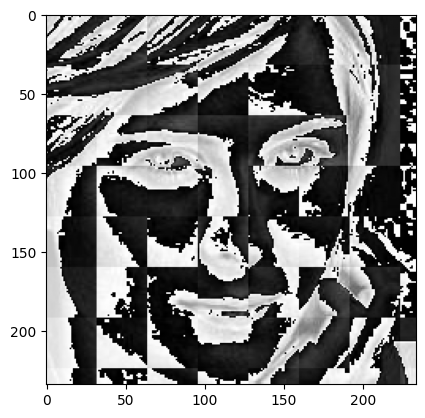

In [24]:
#testing the wavelet transform function
image = cv2.imread('.\\cropped\\maria_sharapova\\sharapova-hits-the-practice-courts-and-met-ball-kids.jpg')
transformed_img = w2d(image, mode='db1', level=5)
plt.imshow(transformed_img, cmap='gray')

In [25]:
X = []
y_labels = []
label_map = {name: idx for idx, name in enumerate(celeb_names)}

for celeb_name in celeb_names:
    celeb_target_path = os.path.join(cropped_dir, celeb_name)
    for img_file in os.scandir(celeb_target_path):
        img_read = cv2.imread(img_file.path)
        img_resized = cv2.resize(img_read, (32, 32))
        img_wav = w2d(img_read, mode='db1', level=5)
        img_wav_resized = cv2.resize(img_wav, (32, 32))
        combined = np.vstack((img_resized.reshape(32*32*3, 1), img_wav_resized.reshape(32*32, 1)))
        X.append(combined.flatten())
        y_labels.append(label_map[celeb_name])

X = np.array(X)
y_labels = np.array(y_labels)
print(f"X shape: {X.shape}, y shape: {y_labels.shape}")

X shape: (187, 4096), y shape: (187,)


In [29]:
X = X.astype(np.float32)
X.dtype

dtype('float32')

In [52]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10))
])

x_train, x_test, y_train, y_test = train_test_split(X, y_labels, train_size=0.8)

pipe.fit(x_train, y_train)
pipe.score(x_test, y_test)

0.8157894736842105

In [53]:
from sklearn.metrics import classification_report


print(classification_report(y_test, pipe.predict(x_test), target_names=celeb_names))

                 precision    recall  f1-score   support

   lionel_messi       0.83      1.00      0.91         5
maria_sharapova       0.78      1.00      0.88         7
  roger_federer       0.67      0.40      0.50         5
serena_williams       1.00      0.56      0.71         9
    virat_kohli       0.80      1.00      0.89        12

       accuracy                           0.82        38
      macro avg       0.82      0.79      0.78        38
   weighted avg       0.83      0.82      0.80        38



In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
# from sklearn.svm import LinearSVC

# models = {
#     'SVC_RBF': {
#         'model': Pipeline([
#             ('scaler', StandardScaler()),
#             ('svc', SVC(kernel='rbf'))
#         ]),
#         'params': {
#             'svc__C': [1, 10, 50],
#             'svc__gamma': ['scale', 0.001, 0.0001]
#         }
#     },

#     'LinearSVC': {
#         'model': Pipeline([
#             ('scaler', StandardScaler()),
#             ('clf', LinearSVC(dual=False, max_iter=10000))
#         ]),
#         'params': {
#             'clf__C': [0.1, 1, 10]
#         }
#     },

#     'LogisticRegression': {
#         'model': Pipeline([
#             ('scaler', StandardScaler()),
#             ('clf', LogisticRegression(max_iter=5000, class_weight='balanced'))
#         ]),
#         'params': {
#             'clf__C': [0.1, 1, 10],
#             'clf__solver': ['lbfgs', 'saga']
#         }
#     },

#     'RandomForest': {
#         'model': RandomForestClassifier(random_state=42, n_jobs=-1),
#         'params': {
#             'n_estimators': [300, 600],
#             'max_depth': [None, 20, 40],
#             'min_samples_split': [2, 5],
#             'class_weight': [None, 'balanced_subsample']
#         }
#     },

#     'HistGradientBoosting': {
#         'model': HistGradientBoostingClassifier(random_state=42),
#         'params': {
#             'learning_rate': [0.03, 0.1],
#             'max_iter': [200, 400],
#             'max_depth': [None, 10],
#             'l2_regularization': [0.0, 1.0]
#         }
#     }
# }

In [56]:
# # Grid Search CV tries every combination for all parameters for ONE MODEL. For more than one models, we still 
# # need a for loop

# from sklearn.model_selection import GridSearchCV, ShuffleSplit


# scores = []
# cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)

# for model_name, model_dict in models.items():
#     pipe = Pipeline([StandardScaler(), model_dict['model']])
#     grid_search_obj = GridSearchCV(pipe, model_dict['params'], cv=cv, return_train_score=False)
#     grid_search_obj.fit(x_train,y_train)
#     scores.append({
#         'model' : model_name,
#         'best parameters' : grid_search_obj.best_params_,
#         'best score' : grid_search_obj.best_score_
#     })

In [ ]:
# scores = pd.DataFrame(scores, columns=['model', 'best parameters', 'best score'])
# scores

My machine will blow off if I run the above grid search with all models and parameters,
so I will go with the SVC model we trained above.

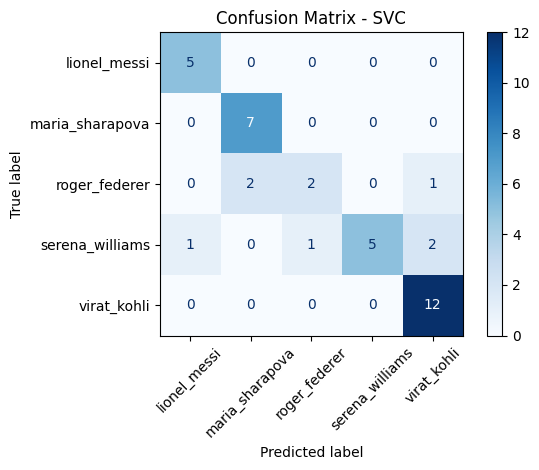

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = pipe.predict(x_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=celeb_names,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - SVC")
plt.tight_layout()
plt.show()

In [58]:
import pickle
import json
import os

with open('sports_person_classifier.pkl', "wb") as f:
    pickle.dump(pipe, f)

# Save class labels
columns_label = label_map if "label_map" in globals() else {name: idx for idx, name in enumerate(celeb_names)}
with open('sports_person_classifier_labels.json', "w") as f:
    json.dump(columns_label, f, indent=2)

print(f"Model saved to: sports_person_classifier.pkl")
print(f"Labels saved to: sports_person_classifier_labels.json")

Model saved to: sports_person_classifier.pkl
Labels saved to: sports_person_classifier_labels.json
